警告: HDF5 文件 'tokamak_mesh_EHL2_66holes.h5' 中缺少 mesh/NUM_SIDESETS 数据集。
成功从 'tokamak_mesh_EHL2_66holes.h5' 读取数据:
  - 节点数量: 20742
  - 单元数量: 40652
  - 发现的区域标记: [1 2 3 4]
  - 发现的 NODESETS 数量: 66
  - 发现的 SIDESETS 数量: 0
节点集信息（每个节点集包含的节点数）：
  - NODESET0001: 12 个节点
  - NODESET0002: 12 个节点
  - NODESET0003: 12 个节点
  - NODESET0004: 12 个节点
  - NODESET0005: 22 个节点
  - NODESET0006: 18 个节点
  - NODESET0007: 22 个节点
  - NODESET0008: 22 个节点
  - NODESET0009: 18 个节点
  - NODESET0010: 22 个节点
  - NODESET0011: 12 个节点
  - NODESET0012: 12 个节点
  - NODESET0013: 12 个节点
  - NODESET0014: 12 个节点
  - NODESET0015: 22 个节点
  - NODESET0016: 22 个节点
  - NODESET0017: 18 个节点
  - NODESET0018: 22 个节点
  - NODESET0019: 22 个节点
  - NODESET0020: 18 个节点
  - NODESET0021: 22 个节点
  - NODESET0022: 22 个节点
  - NODESET0023: 22 个节点
  - NODESET0024: 22 个节点
  - NODESET0025: 22 个节点
  - NODESET0026: 22 个节点
  - NODESET0027: 22 个节点
  - NODESET0028: 22 个节点
  - NODESET0029: 18 个节点
  - NODESET0030: 22 个节点
  - NODESET0031: 22 个节点
  - NODESET0032: 18 个节点

/home/yfz/.conda/envs/OFT-260316/lib/python3.13/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(



正在打开 PyVista 可视化窗口...


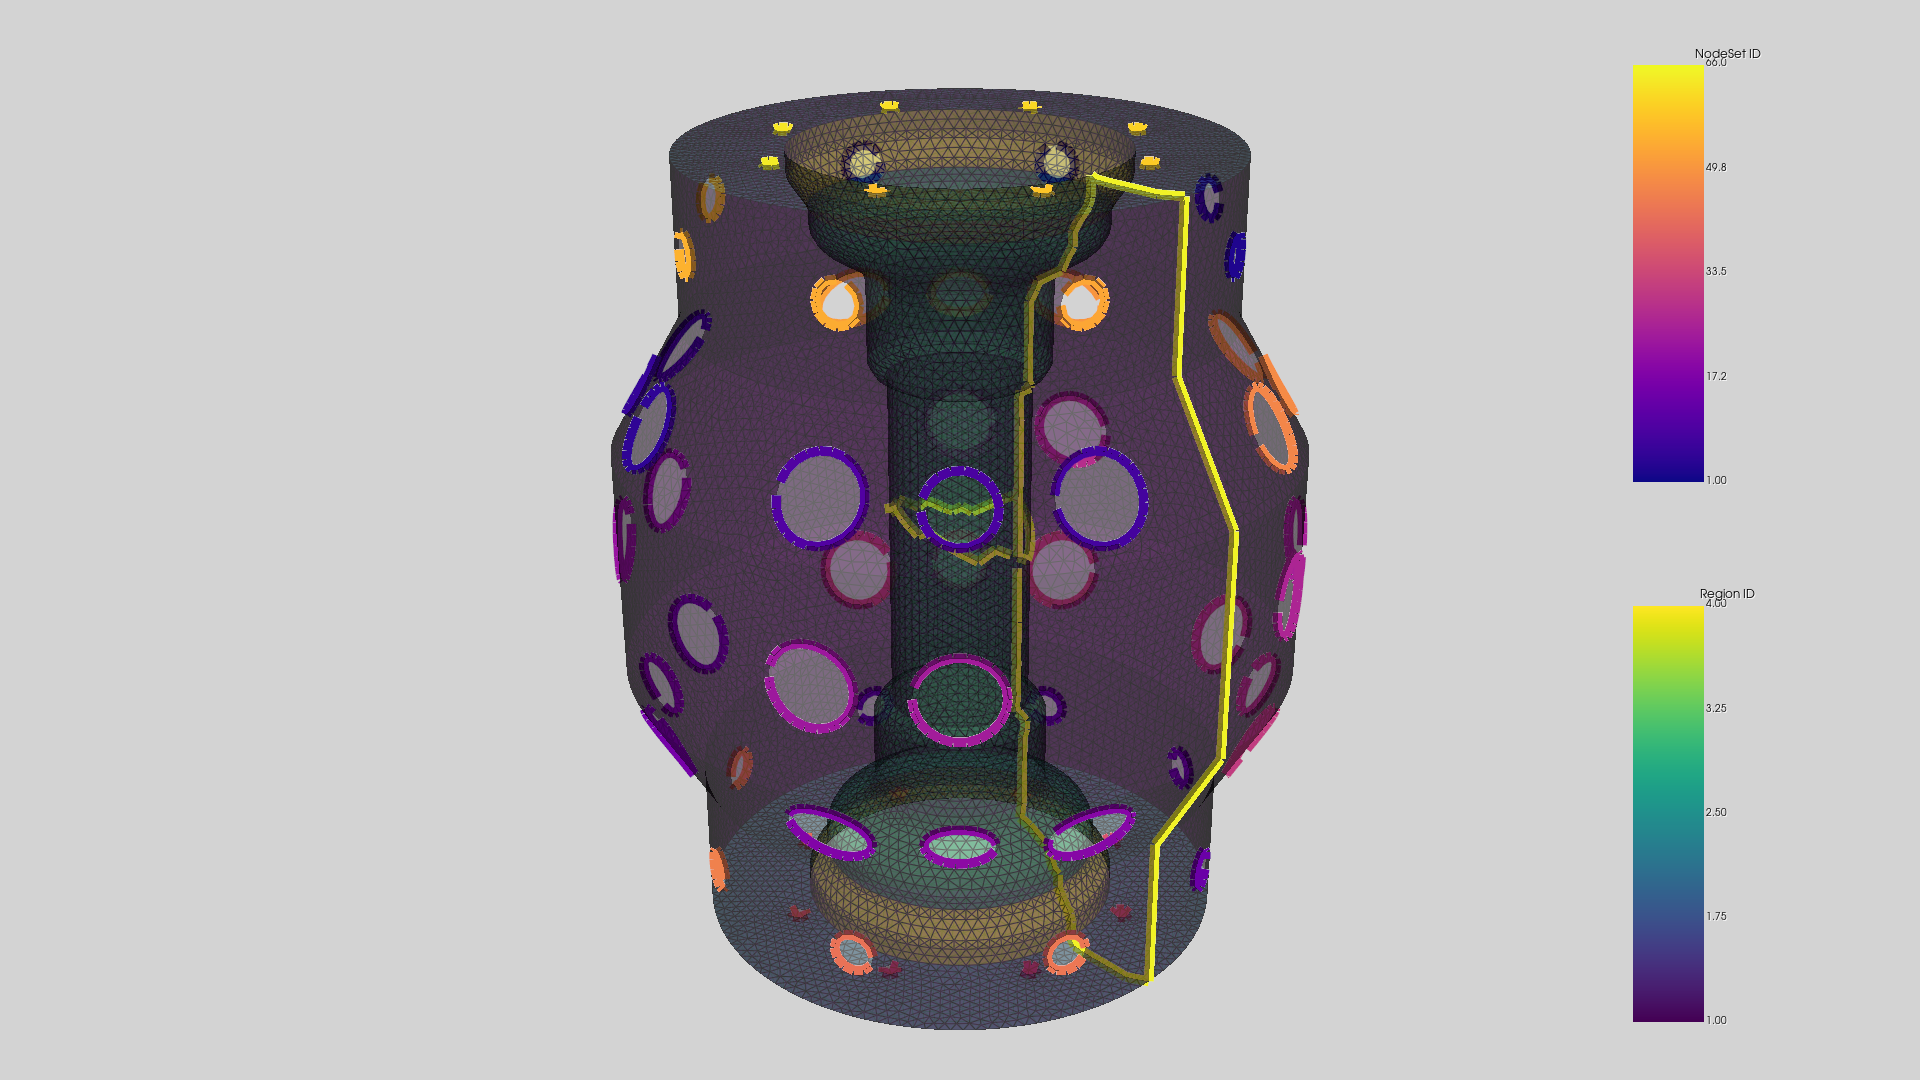

In [1]:
# ==============================================================================
# 7. pyvista可视化检验（增强版：显示 NODESETS 线条）
# ==============================================================================

import pyvista as pv
import numpy as np
import h5py

hdf5_filename = "tokamak_mesh_EHL2_66holes.h5"

try:
    with h5py.File(hdf5_filename, 'r') as f:
        # 检查所需的数据集是否存在
        if 'mesh/R' not in f or 'mesh/LC' not in f or 'mesh/REG' not in f:
            print(f"错误: HDF5 文件 '{hdf5_filename}' 中缺少必要的数据集 ('mesh/R', 'mesh/LC', 'mesh/REG')。")
            exit()
            
        # 读取节点坐标
        nodes = f['mesh/R'][:]
        
        # 读取单元连接 (1-based index)
        elements_1based = f['mesh/LC'][:]
        
        # 读取区域标记
        regions = f['mesh/REG'][:].flatten() # flatten to a 1D array

        num_nodesets = 0
        nodesets = []
        # 检查是否存在 mesh/NUM_NODESETS
        if 'mesh/NUM_NODESETS' not in f:
            print(f"警告: HDF5 文件 '{hdf5_filename}' 中缺少 mesh/NUM_NODESETS 数据集。")
        else:
            # 读取NODESETS数量
            num_nodesets = f['mesh/NUM_NODESETS'][0]

            # 从NODESET0001开始读取
            for i in range(1, num_nodesets + 1):
                nodeset_name = f"NODESET{i:04d}"
                if nodeset_name in f['mesh']:
                    nodesets.append(f['mesh'][nodeset_name][:])
                else:
                    print(f"  - 警告: {nodeset_name} 未找到")

        num_sidesets = 0
        sidesets = []
        # 检查是否存在 mesh/NUM_SIDESETS
        if 'mesh/NUM_SIDESETS' not in f:
            print(f"警告: HDF5 文件 '{hdf5_filename}' 中缺少 mesh/NUM_SIDESETS 数据集。")
        else:
            # 读取SIDESETS数量
            num_sidesets = f['mesh/NUM_SIDESETS'][0]

            # 从SIDSET0001开始读取
            for i in range(1, num_sidesets + 1):
                sideset_name = f"SIDSET{i:04d}"
                if sideset_name in f['mesh']:
                    sidesets.append(f['mesh'][sideset_name][:])
                else:
                    print(f"  - 警告: {sideset_name} 未找到")

except FileNotFoundError:
    print(f"错误: 文件 '{hdf5_filename}' 未找到。请先运行 Gmsh 脚本生成该文件。")
    exit()

print(f"成功从 '{hdf5_filename}' 读取数据:")
print(f"  - 节点数量: {nodes.shape[0]}")
print(f"  - 单元数量: {elements_1based.shape[0]}")
print(f"  - 发现的区域标记: {np.unique(regions)}")
print(f"  - 发现的 NODESETS 数量: {num_nodesets}")
print(f"  - 发现的 SIDESETS 数量: {num_sidesets}")

print("节点集信息（每个节点集包含的节点数）：")
for i, ns in enumerate(nodesets, 1):
    print(f"  - NODESET{i:04d}: {ns.shape[0]} 个节点")


# --- 2. 准备 PyVista 需要的数据格式（曲面网格）---

# PyVista 需要 0-based 索引，并且单元格式为 [n_points, p0, p1, p2, ...]
# 因为我们所有的单元都是三角形，所以 n_points 总是 3

# 将 1-based 索引转换为 0-based
elements_0based = elements_1based - 1

# 创建 PyVista 格式的单元数组
padding = np.full((elements_0based.shape[0], 1), 3, dtype=elements_0based.dtype)
cells = np.hstack((padding, elements_0based))

# --- 3. 构建曲面网格并附加区域标记 ---
mesh = pv.PolyData(nodes, faces=cells)
mesh.cell_data['Region'] = regions

# --- 4. 构建节点集的线条网格 ---
if num_nodesets > 0:
    # 用于存储所有线段的数据
    all_lines = []          # 存储每个线段的 [2, p0, p1]
    node_set_ids = []       # 每个线段对应的节点集编号（从1开始）
    
    for ns_idx, node_indices_1based in enumerate(nodesets, start=1):
        # 转换为0-based索引
        node_indices = node_indices_1based - 1
        
        # 确保节点索引有效
        if np.any(node_indices >= nodes.shape[0]) or np.any(node_indices < 0):
            print(f"警告：节点集 {ns_idx:04d} 包含无效节点索引，跳过")
            continue
        
        # 将相邻节点连接成线段
        for i in range(len(node_indices) - 1):
            p0 = node_indices[i]
            p1 = node_indices[i + 1]
            all_lines.append([2, p0, p1])      # 每个线段：2个点 + 两个节点索引
            node_set_ids.append(ns_idx)        # 线段所属的节点集编号
    
    if all_lines:
        # 转换为 numpy 数组
        lines_array = np.array(all_lines).flatten()  # 一维数组形式
        node_set_ids_array = np.array(node_set_ids)
        
        # 创建线条网格
        lines_mesh = pv.PolyData(nodes, lines=lines_array)
        lines_mesh.cell_data['NodeSetID'] = node_set_ids_array
    else:
        lines_mesh = None
        print("警告：未生成有效的线段，节点集可能为空或无效")
else:
    lines_mesh = None
    print("没有节点集数据，跳过线条可视化")


# --- 5. 创建绘图器并添加网格 ---
cam_position = [
    (-8, 8, 5),  # 相机位置坐标
    (0.0, 0.0, 0.0),  # 焦点坐标
    (0.0, 0.0, 1.0)  # 定义"向上"方向
]
windowsize = [1920, 1080]
pv.OFF_SCREEN = True  # 关键：启用离屏渲染
pv.start_xvfb()       # 启动虚拟显示（可选，部分场景需要）
pv.set_jupyter_backend('static') # Comment to enable interactive PyVista plots

plotter = pv.Plotter(window_size=windowsize)
plotter.set_background('lightgrey')
plotter.camera_position = cam_position

# 添加曲面网格
# 添加曲面网格（颜色条放在右下侧）
plotter.add_mesh(
    mesh,
    scalars='Region',
    cmap='viridis',
    show_edges=True,
    edge_color='black',
    line_width=0,
    opacity=0.5,
    scalar_bar_args={
        'title': 'Region ID',
        'position_x': 0.85,    # 相对位置 x (0~1)
        'position_y': 0.05,    # 相对位置 y (0~1)
        'width': 0.1,          # 宽度
        'height': 0.4,         # 高度
        'vertical': True,      # 竖直方向
        'title_font_size': 12,
        'label_font_size': 10,
        'shadow': True
    }
)

# 添加节点集线条网格（颜色条放在右上侧）
if lines_mesh is not None:
    plotter.add_mesh(
        lines_mesh,
        scalars='NodeSetID',
        cmap='plasma',
        line_width=10,
        show_scalar_bar=True,
        scalar_bar_args={
            'title': 'NodeSet ID',
            'position_x': 0.85,
            'position_y': 0.55,   # 比下方的颜色条高
            'width': 0.1,
            'height': 0.4,
            'vertical': True,
            'title_font_size': 12,
            'label_font_size': 10,
            'shadow': True
        }
    )

# 设置相机视角
plotter.camera_position = cam_position

# 显示交互式窗口
print("\n正在打开 PyVista 可视化窗口...")
plotter.show()